In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\MINA\Documents\WeekilyPrac\Ml_JOUNRAL\ml-learning-journal\Time Series\Datasets\AirPassengers.csv')

df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [2]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
df = df.rename(columns={'#Passengers':'Passengers'})
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


In [5]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [6]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [7]:
df['Month_Name'] = df.index.month_name()

month_avg = df.groupby('Month_Name')['Passengers'].mean()

month_avg

Month_Name
April        267.083333
August       351.083333
December     261.833333
February     235.000000
January      241.750000
July         351.333333
June         311.666667
March        270.166667
May          271.833333
November     232.833333
October      266.583333
September    302.416667
Name: Passengers, dtype: float64

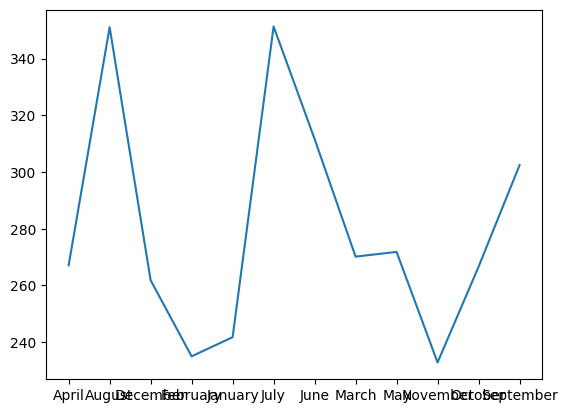

In [8]:
import matplotlib.pyplot as plt

plt.plot(month_avg.index, month_avg.values)
plt.show()

In [9]:
df['Year'] = df.index.year

year_avg = df.groupby('Year')['Passengers'].mean()

year_avg

Year
1949    126.666667
1950    139.666667
1951    170.166667
1952    197.000000
1953    225.000000
1954    238.916667
1955    284.000000
1956    328.250000
1957    368.416667
1958    381.000000
1959    428.333333
1960    476.166667
Name: Passengers, dtype: float64

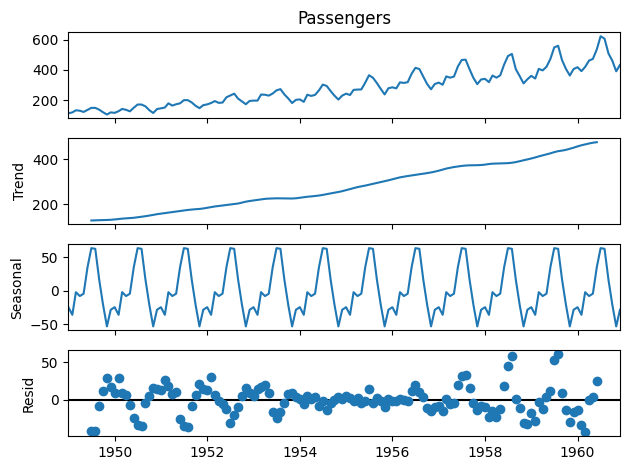

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(df['Passengers'], model='additive', period=12)

decompose.plot()
plt.show()

In [11]:
rolling_mean = df['Passengers'].rolling(window=3).mean()
rolling_std = df['Passengers'].rolling(window=3).std()

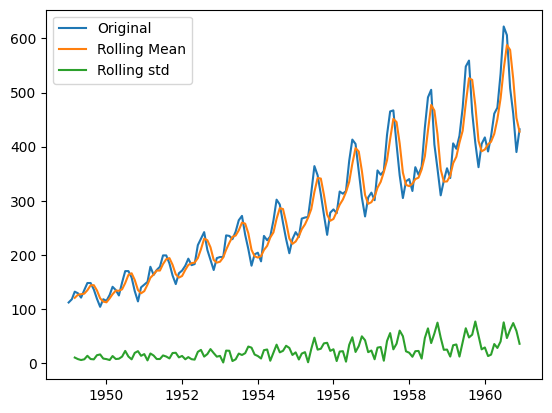

In [12]:
plt.plot(df['Passengers'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling std')

plt.legend()
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(df['Passengers'])

print(results[1])

0.991880243437641


In [14]:
df['Passengers_diff'] = df['Passengers'].diff()

df_diff = df['Passengers_diff'].dropna()

results = adfuller(df_diff)

print(results[1])

0.0542132902838255


In [15]:
if results[1]<0.05:
    print('Stationary')
else:
    print('Non-Stationary')

Non-Stationary


In [16]:
df['Passengers_diff2'] = df['Passengers_diff'].diff()

df_diff2 = df['Passengers_diff2'].dropna()

results = adfuller(df_diff2)

print(results[1])

2.7328918500142407e-29


In [17]:
if results[1]<0.05:
    print('Stationary')
else:
    print('Non-Stationary')

Stationary


## Plot PACF, ACF

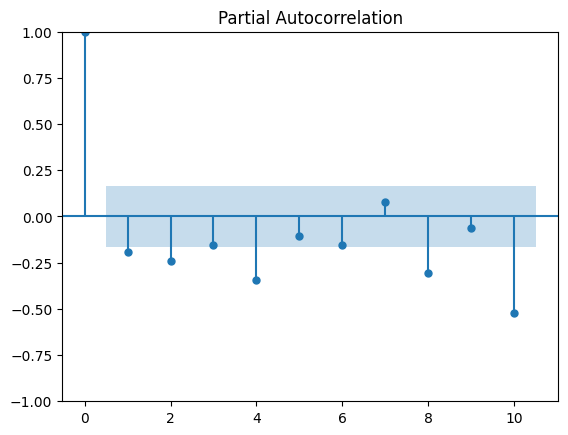

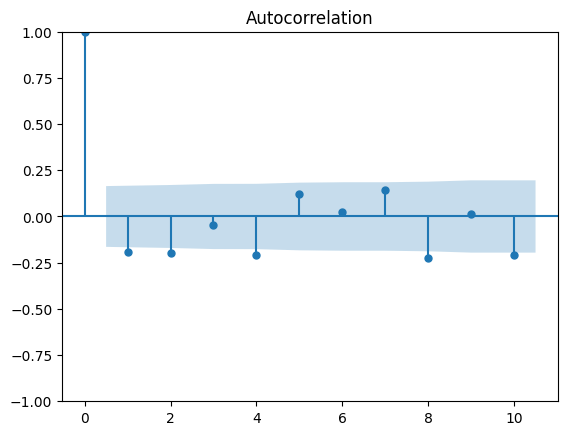

In [18]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

plot_pacf(df_diff2, lags=10)
plot_acf(df_diff2, lags=10)

plt.show()

### Train/Test Split

In [19]:
train = df.iloc[:-30]
test = df.iloc[-30:]

## Arima

In [20]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Passengers'], order=(1,2,1))
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Forecast

In [21]:
forecast = model_fit.forecast(steps=len(test))


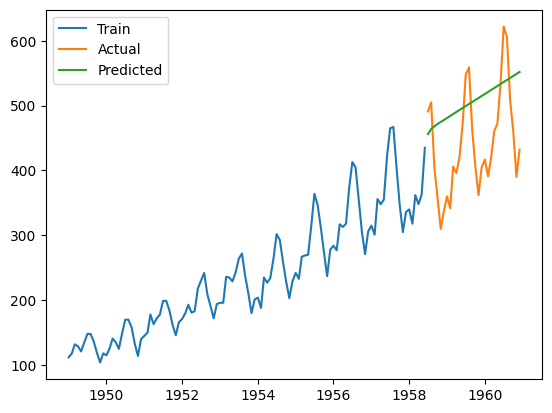

In [22]:
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label="Actual")
plt.plot(test.index, forecast, label='Predicted')

plt.legend()
plt.show()

## SARIMA

In [23]:
results = adfuller(df['Passengers'])

print(results[1])

0.991880243437641


In [24]:
df['Seasonal_diff'] = df['Passengers'].diff(12)

df_seas_diff = df['Seasonal_diff'].dropna()

results = adfuller(df_seas_diff)

results[1]

np.float64(0.011551493085514954)

In [25]:
if results[1]<0.05:
    print('Stationary')
else:
    print('Non-Stationary')

Stationary


In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX 

model = SARIMAX(train['Passengers'], seasonal_order=(1,1,1,12), order=(1,1,1))

model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [27]:
forecast = model_fit.forecast(steps=len(test))

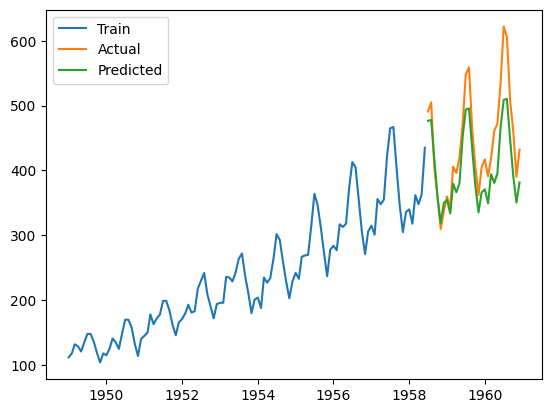

In [28]:
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label="Actual")
plt.plot(test.index, forecast, label='Predicted')

plt.legend()
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['Passengers'], forecast)
rmse = np.sqrt(mean_squared_error(test['Passengers'],forecast))

print(mae)
print(rmse)

40.43792940991217
48.91220468802096


## Exponential Smoothing

In [35]:
from statsmodels.tsa.holtwinters import(SimpleExpSmoothing, Holt, ExponentialSmoothing)

hw_model = ExponentialSmoothing(train['Passengers'], trend='add', seasonal='add', seasonal_periods=12)
hw_fit = hw_model.fit()
hw_forecast = hw_fit.forecast(len(test))

hw_forecast

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


1958-07-01    469.546180
1958-08-01    463.256626
1958-09-01    397.511929
1958-10-01    341.316627
1958-11-01    302.339879
1958-12-01    337.325100
1959-01-01    345.879899
1959-02-01    330.063726
1959-03-01    380.847519
1959-04-01    373.260252
1959-05-01    390.450116
1959-06-01    458.316069
1959-07-01    495.863068
1959-08-01    489.573514
1959-09-01    423.828817
1959-10-01    367.633515
1959-11-01    328.656767
1959-12-01    363.641988
1960-01-01    372.196787
1960-02-01    356.380614
1960-03-01    407.164407
1960-04-01    399.577140
1960-05-01    416.767004
1960-06-01    484.632957
1960-07-01    522.179956
1960-08-01    515.890402
1960-09-01    450.145705
1960-10-01    393.950403
1960-11-01    354.973655
1960-12-01    389.958876
Freq: MS, dtype: float64

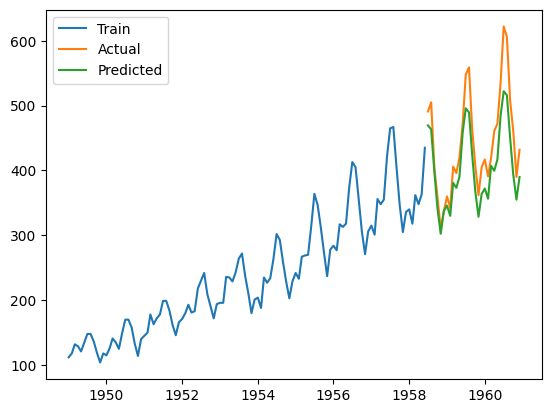

In [36]:
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label="Actual")
plt.plot(test.index, hw_forecast, label='Predicted')

plt.legend()
plt.show()

In [38]:
from statsmodels.tsa.holtwinters import(SimpleExpSmoothing, Holt, ExponentialSmoothing)

hw_model = ExponentialSmoothing(df['Passengers'], trend='add', seasonal='add', seasonal_periods=12)
hw_fit = hw_model.fit()


forecast = hw_fit.forecast(steps=6)

forecast

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


1961-01-01    451.577699
1961-02-01    427.258492
1961-03-01    464.700105
1961-04-01    500.104435
1961-05-01    508.662121
1961-06-01    567.715376
Freq: MS, dtype: float64